# 01: spot, forwards and rates

This is the second of three notebooks in `data_dictionary/`. Notebook 00 mapped where the pull
files come from and what shape they share; this one opens the files that back every spot,
forward and rate computation in the tutorial set, and checks what they actually carry against
what `Catalog.default()` claims about the currency universe. Notebook 02 does the same for the
option surfaces.

The tutorial notebooks build on a `Catalog` and read it as fact: 35 currencies, each with a
spot ticker, a forward root and a point scale. Most of that holds up against the files. Where
it does not, this notebook shows the gap directly rather than describing it.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

# nbconvert runs with this notebook's folder as the working directory, so walk up
# rather than assume how deep the notebook sits.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "data" / "raw").is_dir())
DATA = ROOT / "data" / "raw"
TAU = 1.0 / 12.0

In [2]:
import pyarrow.parquet as pq

## Which currencies each file actually carries

Notebook 00 already found that nine of the 35 currently traded currencies are missing from
`spot_daily.parquet` entirely, reached instead through `spot_fwd_em_daily.parquet` or
`spot_fwd_broad_daily.parquet`. Rather than take that split on faith, the next cell reads all
three files directly and checks each currency's spot ticker against each one.

In [3]:
from fxcarry import Catalog, ParquetSource, SpotForward, reference

catalog = Catalog.default()
print(f"{len(catalog)} currencies in Catalog.default()")

present = {p.name: set(pq.read_table(p, columns=["ticker"])["ticker"].to_pandas().unique())
           for p in [DATA / "spot_daily.parquet", DATA / "spot_fwd_em_daily.parquet",
                     DATA / "spot_fwd_broad_daily.parquet"]}
rows = []
for currency in catalog:
    rows.append({"iso": currency.iso, "pair": currency.pair,
                 **{name: currency.spot_ticker in tickers for name, tickers in present.items()}})
coverage_by_file = pd.DataFrame(rows).set_index("iso")

only_em = coverage_by_file.index[coverage_by_file["spot_fwd_em_daily.parquet"]
                                  & ~coverage_by_file["spot_daily.parquet"]]
only_broad = coverage_by_file.index[coverage_by_file["spot_fwd_broad_daily.parquet"]
                                     & ~coverage_by_file["spot_daily.parquet"]]
none_at_all = coverage_by_file.index[~coverage_by_file.any(axis=1)]

print(f"{int(coverage_by_file['spot_daily.parquet'].sum())} of {len(catalog)} currencies have "
      "a spot ticker in spot_daily.parquet")
print(f"{len(only_em)} more only in spot_fwd_em_daily.parquet: {list(only_em)}")
print(f"{len(only_broad)} more only in spot_fwd_broad_daily.parquet: {list(only_broad)}")
print(f"{len(none_at_all)} in none of the three files: {list(none_at_all)}")
coverage_by_file

35 currencies in Catalog.default()
26 of 35 currencies have a spot ticker in spot_daily.parquet
4 more only in spot_fwd_em_daily.parquet: ['BRL', 'CNH', 'ILS', 'TRY']
5 more only in spot_fwd_broad_daily.parquet: ['CLP', 'COP', 'PEN', 'RON', 'RUB']
0 in none of the three files: []


,pair,spot_daily.parquet,spot_fwd_em_daily.parquet,spot_fwd_broad_daily.parquet
iso,,,,
AUD,AUDUSD,True,False,False
BRL,USDBRL,False,True,False
CAD,USDCAD,True,False,False
CHF,USDCHF,True,False,False
CNH,USDCNH,False,True,False
CLP,USDCLP,False,False,True
COP,USDCOP,False,False,True
CZK,USDCZK,True,False,False
DKK,USDDKK,True,False,False


Every one of the 35 resolves somewhere, just not always in `spot_daily.parquet` on its own.
The nine that need a different file split cleanly between the two extensions: BRL, CNH, ILS
and TRY sit in the EM file, CLP, COP, PEN, RON and RUB in the broad one. A `ParquetSource`
built from only `spot_daily.parquet` would silently drop all nine. Diffing the catalog against
that one file would have flagged them as missing, but only reading the other two files directly
says where each one actually lives.

## Quote direction and the point scale

`notebooks/tutorial/01_catalog.ipynb` already covers quote direction and the NDF-root table,
reading both off the `Currency` dataclass alone; by its own description it never opens a
parquet file. This notebook restates the two together with the point scale, in one table,
because every section from here on reads a real file and needs exactly these three facts to
interpret what it finds there.

Quote direction and the forward root do follow from how a pair is written:
`Currency.quoted_usd_per_fcu` is `pair.endswith("USD")`, and `Currency.fwd_root` is read straight
off the 1M forward ticker each currency was built from. The point scale does not.
`reference.POINT_SCALE` is an explicit per-ISO lookup with a `"default"` fallback, and the point
scale column below carries values no pair string implies: 1 for CLP and COP among others, 100 for
JPY, HUF, INR and THB, and 10,000 wherever the pair falls through to the default. A currency added
to the catalog without its own entry silently takes that default, which is why
`notebooks/tutorial/08_reference.ipynb`'s add-a-currency checklist asks for a `POINT_SCALE` entry
whenever the pair is not a plain four-decimal quote. The next table lays out all 35 currencies at
once.

In [4]:
table = pd.DataFrame([{"iso": c.iso, "pair": c.pair, "usd per fcu": c.quoted_usd_per_fcu,
                       "point scale": c.point_scale, "fwd root": c.fwd_root} for c in catalog]
                     ).set_index("iso")

majors = table.index[table["usd per fcu"]]
ndf_roots = table.index[table["fwd root"].values != table.index.values]
print(f"{len(majors)} currencies quote dollars per foreign unit: {list(majors)}")
print(f"{len(ndf_roots)} currencies trade forwards under a root that differs from the ISO "
      f"code: {list(ndf_roots)}")
# Grouping the scale column shows it is a lookup, not a rule: nothing in AUDUSD, USDJPY or
# USDCLP as strings distinguishes 10,000 from 100 from 1.
for scale, group in table.groupby("point scale"):
    source = "explicit entry" if scale != reference.POINT_SCALE["default"] else "default fallback"
    print(f"point scale {scale:>7,.0f} ({source}): {list(group.index)}")
table

4 currencies quote dollars per foreign unit: ['AUD', 'EUR', 'GBP', 'NZD']
7 currencies trade forwards under a root that differs from the ISO code: ['BRL', 'CLP', 'COP', 'IDR', 'INR', 'PEN', 'TWD']
point scale       1 (explicit entry): ['CLP', 'COP', 'IDR', 'KRW', 'PHP', 'TWD']
point scale     100 (explicit entry): ['HUF', 'INR', 'JPY', 'THB']
point scale  10,000 (default fallback): ['AUD', 'BRL', 'CAD', 'CHF', 'CNH', 'CZK', 'DKK', 'EUR', 'GBP', 'HKD', 'ILS', 'KWD', 'MXN', 'MYR', 'NOK', 'NZD', 'PEN', 'PLN', 'RON', 'RUB', 'SAR', 'SEK', 'SGD', 'TRY', 'ZAR']


,pair,usd per fcu,point scale,fwd root
iso,,,,
AUD,AUDUSD,True,10000.0,AUD
BRL,USDBRL,False,10000.0,BCN
CAD,USDCAD,False,10000.0,CAD
CHF,USDCHF,False,10000.0,CHF
CNH,USDCNH,False,10000.0,CNH
CLP,USDCLP,False,1.0,CHN
COP,USDCOP,False,1.0,CLN
CZK,USDCZK,False,10000.0,CZK
DKK,USDDKK,False,10000.0,DKK


Four majors, AUD, EUR, GBP and NZD, are quoted the other way up from the rest of the panel: a
rise in the pair already means the foreign currency gained, which is why
`Currency.quoted_usd_per_fcu` exists rather than assuming dollars-per-foreign-unit throughout.
Seven more, BRL, CLP, COP, IDR, INR, PEN and TWD, trade their forwards as non-deliverables
under a root that has nothing to do with the ISO code: the Colombian peso's forward points
quote under `CLN`, not `COP`, and the seven roots in the table above are exactly what
`Currency.fwd_ticker` has to get right to find them.

## Coverage decides the usable sample

A ticker existing in a file says nothing about how far back it goes or how gappy it is.
`Quotes.coverage()` reads that off the pivoted monthly panel directly: the first and last date
each column actually has a value, and how many months it has one at all.

In [5]:
source = ParquetSource(DATA / "spot_daily.parquet", DATA / "fwd_points_1m_daily.parquet")
spot = source.quotes(catalog.label_map("spot"), freq="M")
points = source.quotes(catalog.label_map("forward", "1M"), freq="M")
coverage = spot.coverage().join(points.coverage(), lsuffix=" spot", rsuffix=" fwd")
coverage.sort_values("first_valid spot")

,first_valid spot,last_valid spot,n_obs spot,first_valid fwd,last_valid fwd,n_obs fwd
AUD,1983-11-30 00:00:00,2026-07-31 00:00:00,513,1983-12-31 00:00:00,2026-07-31 00:00:00,512
THB,1983-11-30 00:00:00,2026-07-31 00:00:00,513,1995-09-30 00:00:00,2026-07-31 00:00:00,369
SGD,1983-11-30 00:00:00,2026-07-31 00:00:00,513,1988-12-31 00:00:00,2026-07-31 00:00:00,452
SEK,1983-11-30 00:00:00,2026-07-31 00:00:00,513,1988-12-31 00:00:00,2026-07-31 00:00:00,452
NZD,1983-11-30 00:00:00,2026-07-31 00:00:00,513,1988-12-31 00:00:00,2026-07-31 00:00:00,452
NOK,1983-11-30 00:00:00,2026-07-31 00:00:00,513,1988-12-31 00:00:00,2026-07-31 00:00:00,452
MYR,1983-11-30 00:00:00,2026-07-31 00:00:00,513,1999-01-31 00:00:00,2026-07-31 00:00:00,331
MXN,1983-11-30 00:00:00,2026-07-31 00:00:00,513,1997-11-30 00:00:00,2026-07-31 00:00:00,345
KWD,1983-11-30 00:00:00,2025-07-31 00:00:00,483,1996-12-31 00:00:00,2026-07-31 00:00:00,355
TWD,1983-11-30 00:00:00,2026-07-31 00:00:00,513,NaN,NaN,NaN


## What the join into `SpotForward` costs

Building a `SpotForward` panel is stricter than either file on its own: a currency needs a
print in `spot_daily.parquet`, a print in `fwd_points_1m_daily.parquet`, and an entry in the
catalog, before `SpotForward.from_quotes` carries it.

In [6]:
curves = SpotForward.from_quotes(spot, points, catalog, TAU)
print(f"spot carries {len(spot.columns)} currencies")
print(f"1M points carry {len(points.columns)}")
print(f"both, and in the catalog: {len(curves.currencies)}")
dropped = sorted(set(spot.columns) - set(curves.currencies))
print("dropped:", dropped)

spot carries 26 currencies
1M points carry 23
both, and in the catalog: 23
dropped: ['IDR', 'INR', 'TWD']


In [7]:
# The dropped currencies all have a spot print. Checking where their forward points actually
# live, rather than assuming the gap means no data exists, is what "prefer reading the file"
# asks for. Searching both extension files instead of hardcoding which one holds which currency
# costs almost nothing, since a ticker-only read of either is small.
candidates = ["spot_fwd_em_daily.parquet", "spot_fwd_broad_daily.parquet"]
candidate_tickers = {fname: set(pq.read_table(DATA / fname, columns=["ticker"])["ticker"]
                                .to_pandas().unique())
                     for fname in candidates}
for iso in dropped:
    for tenor in ("1M", "3M"):
        ticker = catalog[iso].fwd_ticker(tenor)
        found_in = [fname for fname, tickers in candidate_tickers.items() if ticker in tickers]
        print(f"{iso} {ticker}: {found_in[0] if found_in else 'not found in either file'}")

IDR IHO1M Curncy: spot_fwd_broad_daily.parquet
IDR IHO3M Curncy: spot_fwd_broad_daily.parquet
INR IRN1M Curncy: spot_fwd_em_daily.parquet
INR IRN3M Curncy: spot_fwd_em_daily.parquet
TWD NTN1M Curncy: spot_fwd_em_daily.parquet
TWD NTN3M Curncy: spot_fwd_em_daily.parquet


The points are not missing from the pull, only from the two files this join was handed. IDR's
1M and 3M points live in `spot_fwd_broad_daily.parquet`, INR's and TWD's in
`spot_fwd_em_daily.parquet`, bundled alongside their spot tickers the same way the nine EM and
broad currencies above were. A join built from the wider file set the way
`notebooks/04_hedged_leg_from_first_principles.ipynb` assembles its panel would keep all three;
this narrower one, using only the two files above, is what makes the cost of the join visible in
the first place.

## The coverage picture, as a chart

Sorted by first monthly print, the coverage table becomes a start-date chart across the 26
currencies `spot_daily.parquet` carries.

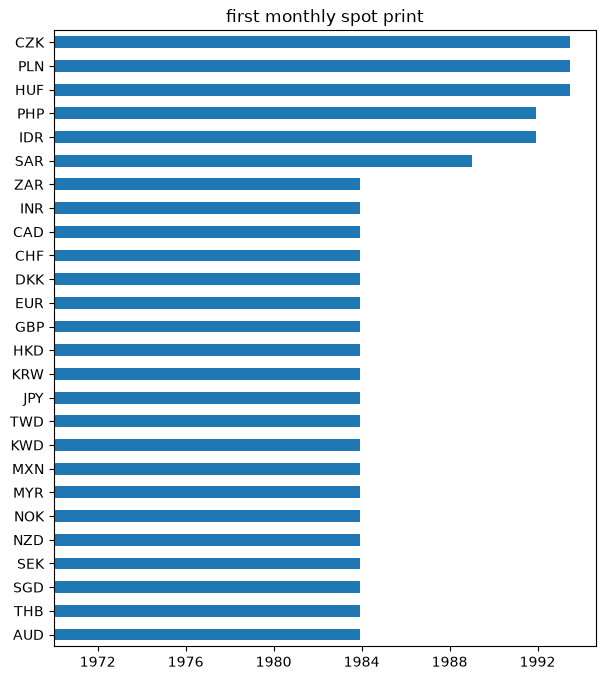

In [8]:
starts = coverage["first_valid spot"].sort_values()
ax = starts.plot.barh(figsize=(7, 8))
ax.set_title("first monthly spot print")
ax.set_xlabel("")
plt.show()

## The forward tenor grid, tenor by tenor

`fwd_points_multi_daily.parquet` carries the full curve, 1W out to 2Y, for every root that has
one, and it is the largest file this notebook touches at 7.1 million rows. `QuoteSource.tickers()`
gets a distinct-ticker list by reading the whole long frame and then taking the unique values in
one column, which means paying for four columns to get one. Reading only the `ticker` column
with `pq.read_table` gets the same list for a fraction of the cost.

In [9]:
import time

grid_path = DATA / "fwd_points_multi_daily.parquet"
n_rows = pq.ParquetFile(grid_path).metadata.num_rows  # file metadata, no column read at all

t0 = time.time()
grid_tickers = pq.read_table(grid_path, columns=["ticker"])["ticker"].to_pandas().unique()
elapsed = time.time() - t0

decoded = [catalog.parse(t) for t in grid_tickers]
undecoded_roots = sorted({t[:3] for t, d in zip(grid_tickers, decoded) if d is None})
found = pd.Series([d.tenor for d in decoded if d is not None]).value_counts()

print(f"{n_rows:,} rows in the file, {len(grid_tickers)} distinct tickers, ticker column "
      f"read in {elapsed:.2f} seconds")
print(f"{len(undecoded_roots)} roots do not decode against Catalog.default(): "
      f"{undecoded_roots}")
found.reindex([t for t in reference.FWD_TENORS if t in found.index]).to_frame("tickers")

7,100,856 rows in the file, 309 distinct tickers, ticker column read in 0.28 seconds
11 roots do not decode against Catalog.default(): ['ATS', 'BEF', 'DEM', 'ESP', 'FIM', 'FRF', 'GRD', 'IEP', 'ITL', 'NLG', 'PTE']


,tickers
1W,23
2W,22
1M,23
2M,23
3M,23
6M,23
9M,23
12M,23
18M,18
2Y,20


The roots that fail to decode are the eleven legacy euro currencies: they trade a forward grid
in this file too, but `Catalog.default()` excludes them, so `catalog.parse` correctly reports
them as unrecognized rather than misreading them as something else. Of the 23 currencies that
do decode, three tenors fall short of the full count, in two different ways: 2W is missing
exactly one currency out of 23, a rounding-sized gap, while the long end thins out for real,
18M down to 18 currencies and 2Y down to 20.

## The rate benchmarks, and how few currencies have one

`SHORT_RATE_TICKERS` is not built from a naming pattern the way the spot and forward tickers
are. Money-market benchmarks share no convention across markets, so `reference.py` writes the
map out currency by currency and tenor by tenor instead of deriving it.

In [10]:
pd.DataFrame(reference.SHORT_RATE_TICKERS).T.fillna("")

,1M,3M,6M,12M
USD,US0001M Index,US0003M Index,US0006M Index,US0012M Index
EUR,EUR001M Index,EUR003M Index,EUR006M Index,EUR012M Index
GBP,BP0001M Index,BP0003M Index,BP0006M Index,BP0012M Index
JPY,JY0001M Index,JY0003M Index,JY0006M Index,JY0012M Index
CHF,SF0001M Index,SF0003M Index,SF0006M Index,SF0012M Index
CAD,CDOR01 Index,CDOR03 Index,CDOR06 Index,
AUD,BBSW1M Index,BBSW3M Index,BBSW6M Index,
NZD,NDBB1M Index,NDBB3M Index,,
SEK,STIB1M Index,STIB3M Index,STIB6M Index,
NOK,,NIBOR3M Index,NIBOR6M Index,


In [11]:
rates = ParquetSource(DATA / "fx_short_rate_daily.parquet")
with_benchmark = sorted(set(reference.SHORT_RATE_TICKERS) & set(catalog.isos))

print(f"{len(rates.tickers())} rate tickers in the pull")
# The brief's version printed len(catalog) next to len(SHORT_RATE_TICKERS) directly, which
# overstates the overlap by one: SHORT_RATE_TICKERS also keys USD, the domestic leg every pair
# already prices against, and USD has no pair of its own so it is never a catalog member.
# Intersecting with catalog.isos is what actually answers how many catalog currencies carry a
# benchmark of their own.
print(f"{len(catalog)} currencies in the catalog, {len(with_benchmark)} carry a benchmark of "
      f"their own out of {len(reference.SHORT_RATE_TICKERS)} keys in SHORT_RATE_TICKERS "
      "(the extra key is USD, the domestic leg)")

52 rate tickers in the pull
35 currencies in the catalog, 19 carry a benchmark of their own out of 20 keys in SHORT_RATE_TICKERS (the extra key is USD, the domestic leg)


Only 19 of the catalog's 35 currencies carry a pulled rate. That is not enough to build the
book on those curves alone, and it is why `SpotForward.implied_foreign_rate` inverts covered
parity instead of pulling a foreign rate: it backs the foreign rate out of the domestic one and
the forward discount, which needs nothing from this file. `fx_short_rate_daily.parquet` still
earns its place as the direct check on that inversion for the currencies it does reach, but for
most of the panel there is no money-market curve to check against at all.

## The dollar indices

Two broad dollar gauges live in `fx_dollar_index_daily.parquet`, quoted two-sided even though
neither is a currency pair. Notebook 00 already noted that neither feeds a currency-level
calculation directly: they are a market-wide comparison point, not a leg of anything the
library prices.

['DXY Curncy', 'BBDXY Index']


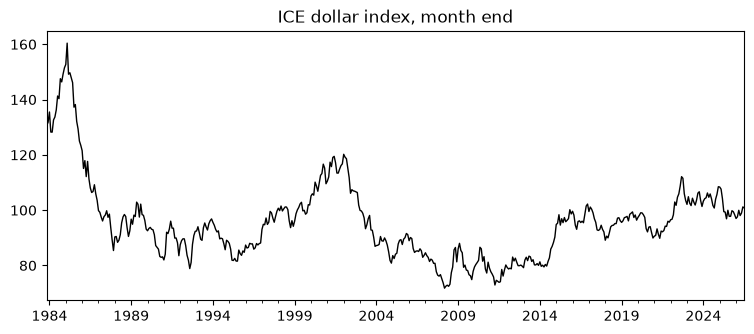

In [12]:
dxy = ParquetSource(DATA / "fx_dollar_index_daily.parquet")
print(list(dxy.tickers()))
ax = dxy.panel({"DXY Curncy": "DXY"}, freq="M").plot(figsize=(9, 3.5), color="black",
                                                     linewidth=1, legend=False)
ax.set_title("ICE dollar index, month end")
plt.show()

## Carry across the panel

Everything above stopped at what the files hold. `curves`, built earlier in the join, is
already the thing the tutorial notebooks price off, so the last cell here uses it rather than
building anything new: the most recent month's annualized carry, one bar per currency.

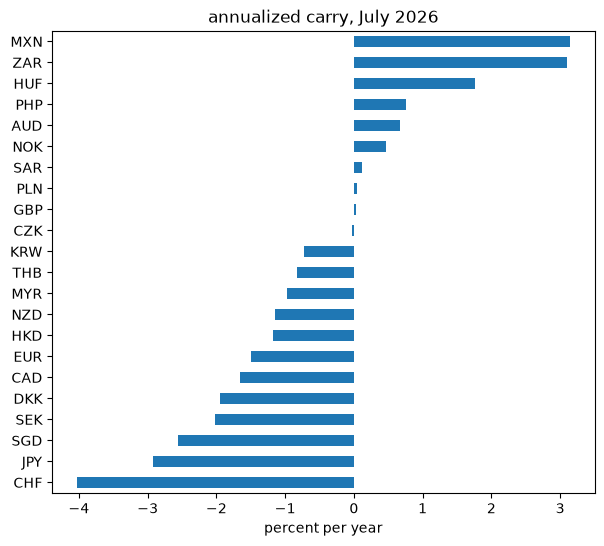

In [13]:
ax = (curves.carry.iloc[-1].dropna().sort_values() * 100).plot.barh(figsize=(7, 6))
ax.set_title(f"annualized carry, {curves.carry.index[-1]:%B %Y}")
ax.set_xlabel("percent per year")
plt.show()